In [1]:
from util.text_util import join_texts
%load_ext autoreload
%autoreload 2

# Load the BPMN Dataset

In [2]:
from mcp4cm.bpmn.dataloading.dataloading import BPMNModelCollection
from mcp4cm.bpmn.dataloading.bpmn_dataset import BPMNDataset
from mcp4cm.dataloading import load_dataset
from mcp4cm.base import DatasetType

Defining file path for saving dataset and loading it later on.

In [3]:
bpmn_dataset = load_dataset(path='data/bpmnmodelset', dataset_type=DatasetType.BPMNMODELSET, bpmn_model_collection=BPMNModelCollection.BPMAI)

In [4]:
from mcp4cm.bpmn.data_extraction import extract_names_from_models

use_types = True

if use_types:
    key = 'names_with_types'
    file_path = 'data/bpmnmodelset/processed/culled_with_typed_names.csv'
    empty_name = 'unknown type: empty name'
else:
    key = 'names'
    file_path = 'data/bpmnmodelset/processed/culled_with_names.csv'
    empty_name = 'empty name'


extract_names_from_models(bpmn_dataset, use_types=use_types, include_texts=True, include_documentation=True)


In [5]:

from bpmn.filter_functions import filter_empty_models, filter_models_by_min_element_count, \
    filter_models_by_max_element_count, filter_models_by_element_count, filter_models_by_empty_name_percentage, \
    filter_models_by_dummy_words, filter_models_by_median_name_length
from mcp4cm.dataloading import Dataset

print(bpmn_dataset)
Dataset.apply_filters(
    dataset=bpmn_dataset,
    filters=[
        filter_empty_models,
        filter_models_by_min_element_count,
        filter_models_by_max_element_count,
        filter_models_by_element_count,
        filter_models_by_empty_name_percentage,
        #filter_models_by_dummy_words
        filter_models_by_median_name_length,
    ],
)

print(bpmn_dataset)

Dataset(name=BPMAI Dataset, models=18812)
Filtered out models where every element is unnamed: 737
Filtered out models with element counts smaller than 5: 186
Filtered out models with element counts greater than 200: 375
Filtered out models with element counts outside of 5 and 200: 0
Filtered out models with a empty name percentage higher than 0.35: 3
Filtered out models with a median name length smaller than 4: 8129
Dataset(name=BPMAI Dataset, models=9382)


In [6]:
from mcp4cm.language_detection import extract_dataset_languages, get_models_by_language

extract_dataset_languages(bpmn_dataset, text_key=key, empty_name=empty_name, override=True)


Language Extraction Progress:   0%|          | 0/9382 [00:00<?, ?it/s]

In [7]:
language_dict = get_models_by_language(bpmn_dataset, print_counts=True)

Language Distribution Across Models:
Language: de, Count: 2796
Language: en, Count: 4500
Language: cs, Count: 87
Language: es, Count: 304
Language: fr, Count: 236
Language: sl, Count: 394
Language: it, Count: 271
Language: sv, Count: 197
Language: pl, Count: 74
Language: ru, Count: 91
Language: nl, Count: 84
Language: sk, Count: 56
Language: pt, Count: 60
Language: et, Count: 37
Language: no, Count: 34
Language: ca, Count: 19
Language: hr, Count: 8
Language: hu, Count: 5
Language: el, Count: 17
Language: ro, Count: 19
Language: vi, Count: 4
Language: lv, Count: 9
Language: af, Count: 6
Language: sw, Count: 4
Language: id, Count: 14
Language: da, Count: 16
Language: ko, Count: 4
Language: fi, Count: 13
Language: zh-cn, Count: 9
Language: tl, Count: 4
Language: so, Count: 3
Language: bg, Count: 2
Language: lt, Count: 1
Language: cy, Count: 3
Language: sq, Count: 1


In [8]:
from mcp4cm.language_detection import filter_models_by_language
english_dataset = filter_models_by_language(bpmn_dataset, 'en', key=key, empty_name=empty_name)

#language_dict = get_models_by_language(english_dataset)
print(f"Filtered Dataset to {len(english_dataset)} English models.")

del bpmn_dataset



Filtered Dataset to 4500 English models.


In [9]:
file_path = 'data/bpmnmodelset/processed/bpmai/english_typed_models.csv'
BPMNDataset.to_csv(english_dataset, file_path);
print(f"Saved {len(english_dataset)} models in dataset {english_dataset.name} to csv file")


Saved 4500 models in dataset BPMAI Dataset to csv file



=== Dataset Statistics ===
Hash calculation and duplicate detection took 0.04 seconds.
Total number of models: 4500
Total unique files: 3972
Total duplicate files: 528
Number of duplicate groups: 244


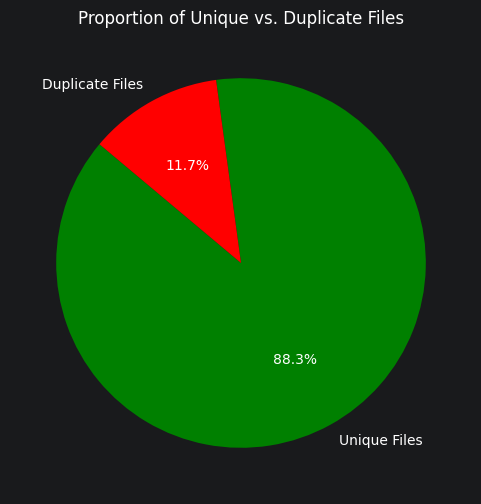

In [10]:
from mcp4cm.duplicate_detection import detect_duplicates_by_hash
hash_unique, hash_duplicate = detect_duplicates_by_hash(english_dataset, key=key, inplace=False, plt_fig=True, print_results=True)


creating tfidf for names_with_types
Generating Connectivity Graph
Connectivity Graph Done
Calculating connected Components
Calculating connected Components Done
Number of components: 3732
Finding unique files:
Creating Duplicate Groups

=== Dataset Statistics ===
Total files processed: 4500
Total unique files: 3290
Total duplicate files: 1210
Number of duplicate groups: 442


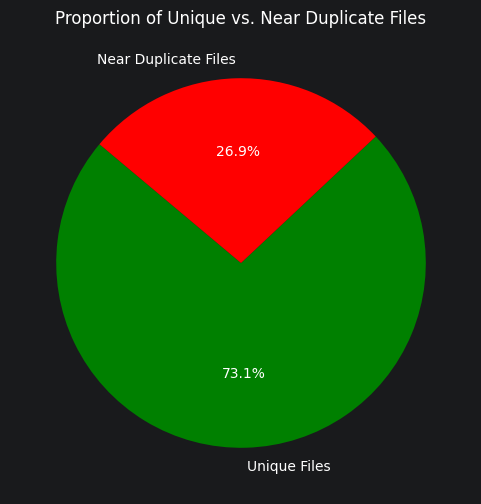

In [11]:
from mcp4cm.duplicate_detection import tfidf_near_duplicate_detector
unique_dataset, duplicate_dataset = tfidf_near_duplicate_detector(english_dataset,key=key, threshold=0.95, inplace=False, plt_fig=True, print_results=True)

In [12]:
file_path = 'data/bpmnmodelset/processed/bpmai/english_typed_deduplicated_models.csv'
BPMNDataset.to_csv(unique_dataset, file_path);

BPMNDataset.to_files(unique_dataset, output_directory='data/export/bpmai_typed_clean', include_svg=True)

In [13]:
#duplicate_file_path = 'data/bpmnmodelset/processed/bpmai/duplicate_models.csv'
#BPMNDataset.to_csv(duplicate_dataset, duplicate_file_path);